In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.font_manager as font_manager
from adjustText import adjust_text

font_dir = Path("/Users/sophiazhang/anaconda3/envs/shuoz/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf")
font_paths = [
    font_dir / "Myriad Pro Regular.ttf",
    font_dir / "Myriad Pro Bold.ttf",
    font_dir / "MYRIADPRO-SEMIBOLD.OTF"
]

for path in font_paths:
    font_manager.fontManager.addfont(str(path))

plt.rcParams["font.family"] = "Myriad Pro"

fs=16
fss=14

In [2]:
RESULTS_DIR = Path("./results")
CSV_SECTOR = RESULTS_DIR / "sector_level_digital_metrics_2000_2020.csv"
RESULTS_DIR.mkdir(exist_ok=True)

# Nice colour palette (cyan + coral + grey)
COLOR_2000 = "#F04E33"
COLOR_2020 = "#3B6597"
COLOR_REF  = "#555555"

GROUP_COLORS = {"NDP": "#999999", "DCP": "#1BB3C8", "DP": "#EF6A62"}

def save_tight(fig, filename, dpi=300):
    fp = RESULTS_DIR / filename
    fig.tight_layout()
    fig.savefig(fp, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {fp}")

In [3]:
df = pd.read_csv(CSV_SECTOR)
df["year"] = df["year"].astype(int)
# only keep 2000 & 2020 for comparison plots
df00 = df[df["year"] == 2000].copy()
df20 = df[df["year"] == 2020].copy()

df_cmp = df00.merge(
    df20,
    on="sector_index",
    suffixes=("_2000", "_2020"),
    how="inner",
)

# use 2020 labels 
df_cmp["sector_name"] = df_cmp["sector_name_2020"]
df_cmp["group"] = df_cmp["group_2020"]

eps = 1e-12
df_cmp["DP_Total_share_2000"] = df_cmp["DP_TotalEffect_t_i_2000"] / (df_cmp["TotalVA_t_i_2000"] + eps)
df_cmp["DP_Total_share_2020"] = df_cmp["DP_TotalEffect_t_i_2020"] / (df_cmp["TotalVA_t_i_2020"] + eps)

df_cmp["DP_Support_share_2020"] = df_cmp["DP_Support_t_i_2020"] / (df_cmp["TotalVA_t_i_2020"] + eps)
df_cmp["DP_FinalDemand_share_2020"] = df_cmp["DP_FinalDemand_t_i_2020"] / (df_cmp["TotalVA_t_i_2020"] + eps)
df_cmp["DP_Support_share_2000"] = df_cmp["DP_Support_t_i_2000"] / (df_cmp["TotalVA_t_i_2000"] + eps)
df_cmp["DP_FinalDemand_share_2000"] = df_cmp["DP_FinalDemand_t_i_2000"] / (df_cmp["TotalVA_t_i_2000"] + eps)

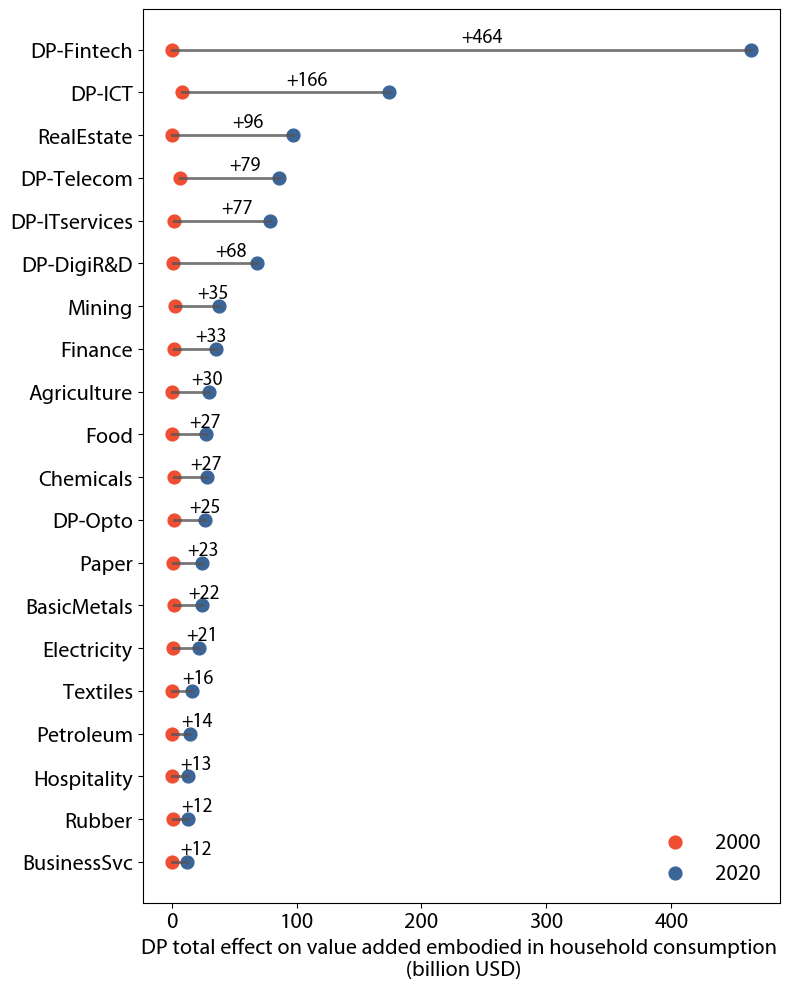

Saved: results/top20_DP_TotalEffect_2000_vs_2020.png


In [14]:
# FIGURE 1: TOP sectors by increase in DP_TotalEffect (absolute), 2020 vs 2000
# =========================
top_n = 20
df_top = df_cmp.copy()
num_cols = df_top.select_dtypes(include=[np.number]).columns
df_top[num_cols] = df_top[num_cols] / 1000.0  # million -> billion
df_top["delta_DP_TotalEffect_abs"] = (
    df_top["DP_TotalEffect_t_i_2020"] - df_top["DP_TotalEffect_t_i_2000"]
)
df_top = (
    df_top.sort_values("delta_DP_TotalEffect_abs", ascending=False)
          .head(top_n)
)

# reverse order for plotting
df_plot = df_top.iloc[::-1].reset_index(drop=True)
y_pos = np.arange(len(df_plot))

fig, ax = plt.subplots(figsize=(8, 0.45 * top_n + 1), facecolor="none")

# connecting lines
for i in range(len(df_plot)):
    x0 = df_plot.loc[i, "DP_TotalEffect_t_i_2000"]
    x1 = df_plot.loc[i, "DP_TotalEffect_t_i_2020"]
    ax.plot([x0, x1], [i, i],
            color=COLOR_REF, linewidth=2, alpha=0.8)

# lollipop points
ax.scatter(df_plot["DP_TotalEffect_t_i_2000"], y_pos,
           color=COLOR_2000, s=85, label="2000")
ax.scatter(df_plot["DP_TotalEffect_t_i_2020"], y_pos,
           color=COLOR_2020, s=85, label="2020")

# --- Δ annotations (key addition) ---
for i in range(len(df_plot)):
    delta = df_plot.loc[i, "delta_DP_TotalEffect_abs"]
    x0 = df_plot.loc[i, "DP_TotalEffect_t_i_2000"]
    x1 = df_plot.loc[i, "DP_TotalEffect_t_i_2020"]

    ax.text(
        0.5 * (x0 + x1),     
        i+0.3,
        f"+{delta:,.0f}",
        va="center",
        ha="left",
        fontsize=fss
    )

# axis formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot["sector_name"], fontsize=fs)
ax.set_xlabel(
    "DP total effect on value added embodied in household consumption \n (billion USD)",
    fontsize=fs
)
ax.tick_params(axis="x", labelsize=fs)
ax.legend(fontsize=fs, frameon=False)
ax.set_facecolor("none")

save_tight(fig, f"top{top_n}_DP_TotalEffect_2000_vs_2020.png")

In [7]:
print(df_plot["sector_name"], df_plot["DP_TotalEffect_t_i_2000"], df_plot["DP_TotalEffect_t_i_2020"])

0       BusinessSvc
1            Rubber
2       Hospitality
3         Petroleum
4          Textiles
5       Electricity
6       BasicMetals
7             Paper
8           DP-Opto
9         Chemicals
10             Food
11      Agriculture
12          Finance
13           Mining
14       DP-DigiR&D
15    DP-ITservices
16       DP-Telecom
17       RealEstate
18           DP-ICT
19       DP-Fintech
Name: sector_name, dtype: object 0      625.697790
1     1161.522088
2      491.338818
3      494.000857
4      545.244066
5     1330.126411
6     2098.030730
7      957.061819
8     1899.474936
9     1777.119152
10     280.464540
11     680.477995
12    1822.993501
13    3043.670449
14     824.622616
15    1723.843427
16    6738.714304
17     559.024889
18    8652.710679
19      66.770681
Name: DP_TotalEffect_t_i_2000, dtype: float64 0      12595.751688
1      13481.390999
2      13483.653037
3      14917.534523
4      16544.393769
5      22011.705497
6      24566.945560
7      24385.522968
8

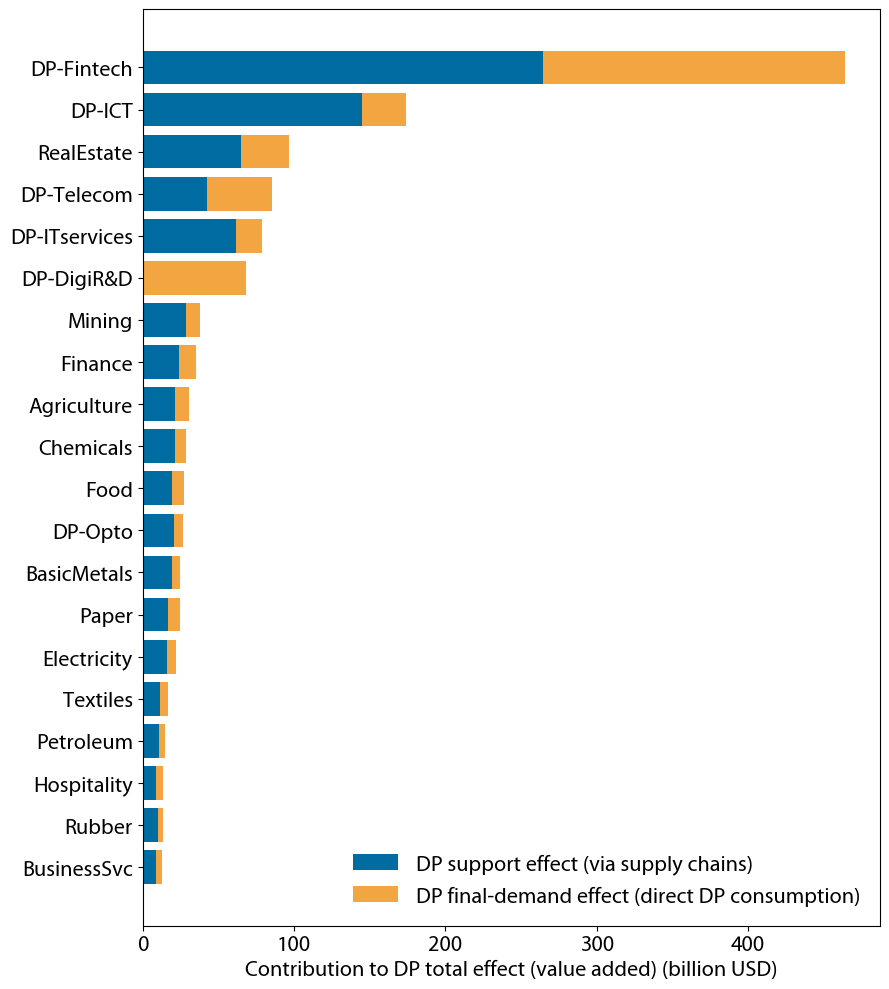

Saved: results/top20_DP_effect_decomposition_2020.png


In [15]:
# FIGURE 2: 2020 sector decomposition (Support vs Final-demand), TOP sectors
# =========================
top_n2 = 20
df_2020 = df20.copy()
num_cols = df_2020.select_dtypes(include=[np.number]).columns
df_2020[num_cols] = df_2020[num_cols] / 1000.0  # million -> billion
df_2020["DP_Total_share_2020"] = df_2020["DP_TotalEffect_t_i"] / (df_2020["TotalVA_t_i"] + eps)

# choose "top sectors" by DP_TotalEffect in 2020 (absolute)
df_2020_top = df_2020.sort_values("DP_TotalEffect_t_i", ascending=False).head(top_n2).iloc[::-1]
y_pos = np.arange(len(df_2020_top))
fig, ax = plt.subplots(figsize=(9, 0.45 * top_n2 + 1), facecolor="none")
ax.barh(
    y_pos,
    df_2020_top["DP_Support_t_i"],
    color="#006CA2",
    label="DP support effect (via supply chains)",
)
ax.barh(
    y_pos,
    df_2020_top["DP_FinalDemand_t_i"],
    left=df_2020_top["DP_Support_t_i"],
    color="#F2A541",
    label="DP final-demand effect (direct DP consumption)",
)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_2020_top["sector_name"], fontsize=fs)
ax.tick_params(axis="x", labelsize=fs)
ax.set_xlabel("Contribution to DP total effect (value added) (billion USD)", fontsize=fs)
# ax.set_title(f"Decomposing DP total effect in 2020 (top {top_n2} sectors)", fontsize=fs)
ax.legend(fontsize=fs, frameon=False)
ax.set_facecolor("none")

save_tight(fig, f"top{top_n2}_DP_effect_decomposition_2020.png")

In [12]:
print(df_2020_top["sector_name"], df_2020_top["DP_Support_t_i"],df_2020_top["DP_FinalDemand_t_i"])

1630      BusinessSvc
1609           Rubber
1627      Hospitality
1606        Petroleum
1603         Textiles
1619      Electricity
1604            Paper
1611      BasicMetals
1681          DP-Opto
1602             Food
1607        Chemicals
1598      Agriculture
1628          Finance
1601           Mining
1689       DP-DigiR&D
1686    DP-ITservices
1685       DP-Telecom
1629       RealEstate
1682           DP-ICT
1687       DP-Fintech
Name: sector_name, dtype: object 1630      8743.827163
1609     10301.989980
1627      8984.285112
1606     10934.942855
1603     11688.745730
1619     16155.173394
1604     16956.848507
1611     19075.521407
1681     20342.086717
1602     19238.028936
1607     21029.227734
1598     21048.859071
1628     24096.668148
1601     28319.719435
1689       258.385670
1686     61901.604736
1685     42394.607557
1629     64992.065383
1682    144735.045228
1687    264210.233252
Name: DP_Support_t_i, dtype: float64 1630      3851.924526
1609      3179.401020
1627  

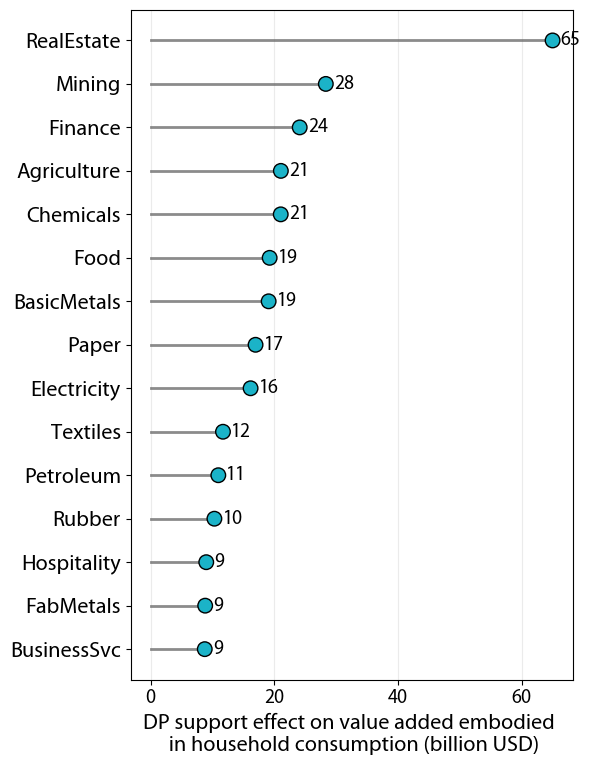

Saved: results/top15_nonDP_hubs_DP_support_2020.png


In [ ]:
# ---- 1) filter: year + non-DP sectors (NDP) ----
df_y = df20[df20["group"].isin(["NDP"])].copy()
df_y["DP_Support_t_i"] = pd.to_numeric(df_y["DP_Support_t_i"], errors="coerce")
df_y = df_y.dropna(subset=["DP_Support_t_i"])

# ---- 2) top N hubs by DP support ----
df_top = df_y.sort_values("DP_Support_t_i", ascending=False).head(15).copy()
df_top = df_top.sort_values("DP_Support_t_i", ascending=True).reset_index(drop=True)

# convert to billion USD (if VALUE_COL is in million USD)
df_top["support_billion"] = df_top["DP_Support_t_i"] / 1000.0

# ---- 3) lollipop plot ----
y_pos = np.arange(len(df_top))
x = df_top["support_billion"].values

colors = np.where(df_top["group"].values == "NDP", "#1BB3C8", "#999999")

fig, ax = plt.subplots(figsize=(6, 0.45 * 15 + 1), facecolor="none")
for i in range(len(df_top)):
    ax.plot([0, x[i]], [i, i], linewidth=2, alpha=0.8, color="#6E6E6E")

ax.scatter(x, y_pos, s=110, color=colors, edgecolor="black", linewidth=1.0, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_top["sector_name"], fontsize=fs)
ax.set_xlabel("DP support effect on value added embodied \n in household consumption (billion USD)", fontsize=fs)
ax.tick_params(axis="x", labelsize=fss)

# annotate values to the right of each dot
offset = x.max() * 0.02 if x.max() > 0 else 0.02
for i in range(len(df_top)):
    ax.text(x[i] + offset, i, f"{x[i]:.0f}", va="center", ha="left", fontsize=fss)

# from matplotlib.lines import Line2D
# legend_elems = [
#     Line2D([0], [0], marker='o', color='none', label='NDP', markerfacecolor="#999999", markersize=9),
#     Line2D([0], [0], marker='o', color='none', label='DCP', markerfacecolor="#1BB3C8", markersize=9),
# ]
# ax.legend(handles=legend_elems, frameon=False, fontsize=fs, loc="lower right")

ax.grid(axis="x", alpha=0.25)
ax.set_facecolor("none")
save_tight(fig, f"top15_nonDP_hubs_DP_support_2020.png")

In [49]:
print(df_top["sector_name"], df_top["support_billion"])

0     BusinessSvc
1       FabMetals
2     Hospitality
3          Rubber
4       Petroleum
5        Textiles
6     Electricity
7           Paper
8     BasicMetals
9            Food
10      Chemicals
11    Agriculture
12        Finance
13         Mining
14     RealEstate
Name: sector_name, dtype: object 0      8.743827
1      8.811011
2      8.984285
3     10.301990
4     10.934943
5     11.688746
6     16.155173
7     16.956849
8     19.075521
9     19.238029
10    21.029228
11    21.048859
12    24.096668
13    28.319719
14    64.992065
Name: support_billion, dtype: float64


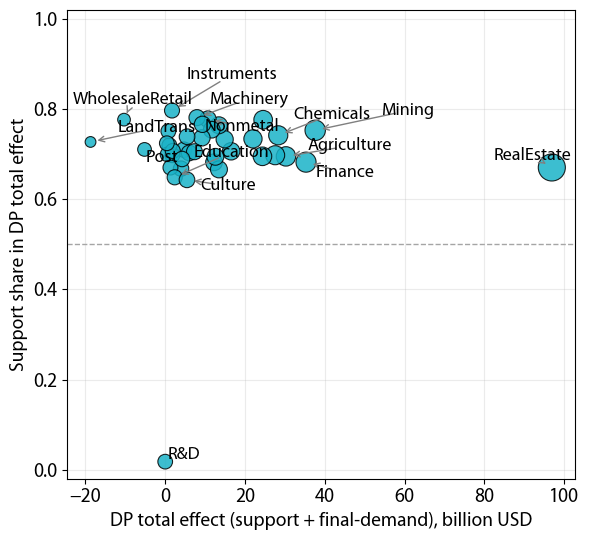

Saved: results/composition_map_nonDP_total_vs_supportshare_2020.png


In [55]:
df_nonDP = df20[df20["group"].isin(["NDP"])].copy()
df_nonDP["support_bil"] = df_nonDP["DP_Support_t_i"] / 1000
df_nonDP["final_bil"]   = df_nonDP["DP_FinalDemand_t_i"] / 1000
df_nonDP["total_bil"]   = (df_nonDP["DP_Support_t_i"] + df_nonDP["DP_FinalDemand_t_i"]) / 1000
eps = 1e-6  # to avoid log(0)
df_nonDP["support_share"] = df_nonDP["support_bil"] / (df_nonDP["total_bil"] + eps)

fig, ax = plt.subplots(figsize=(6, 5.5), facecolor="none")
color_map = {"NDP": "#1BB3C8", "DCP": "#999999"}
# size encode total effect (bigger = larger total)
tmin, tmax = df_nonDP["total_bil"].min(), df_nonDP["total_bil"].max()
# avoid division by zero if all totals are equal
if tmax > tmin:
    size = 60 + (df_nonDP["total_bil"] - tmin) / (tmax - tmin) * (380 - 60)
else:
    size = np.full(len(df_nonDP), 160.0)

for g in ["NDP", "DCP"]:
    sub = df_nonDP[df_nonDP["group"] == g]
    ax.scatter(
        sub["total_bil"],
        sub["support_share"],
        s=size[sub.index],
        color=color_map[g],
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        label=g,
        zorder=3
    )

# reference line: 50% support share
ax.axhline(0.5, linestyle="--", color="gray", linewidth=1, alpha=0.7, zorder=1)

ax.set_xlabel("DP total effect (support + final-demand), billion USD", fontsize=fss)
ax.set_ylabel("Support share in DP total effect", fontsize=fss)
ax.set_ylim(-0.02, 1.02)

ax.tick_params(axis="both", labelsize=fss)
ax.grid(alpha=0.25)
ax.set_facecolor("none")

# ax.legend(frameon=False, fontsize=fss, loc="lower right")

# 1) DP total effect: top 5 and bottom 3
df_top_total = df_nonDP.nlargest(5, "total_bil").copy()
df_bot_total = df_nonDP.nsmallest(3, "total_bil").copy()

# 2) support_share: top 3 and bottom 3
df_top_share = df_nonDP.nlargest(3, "support_share").copy()
df_bot_share = df_nonDP.nsmallest(3, "support_share").copy()

# combine + deduplicate by sector_name (or sector_index if you prefer)
df_annot = pd.concat([df_top_total, df_bot_total, df_top_share, df_bot_share], ignore_index=True)
df_annot = df_annot.drop_duplicates(subset=["sector_name"]).copy()
# --- annotate ---
texts = []
for _, r in df_annot.iterrows():
    # optional: add a tiny offset so text doesn't sit exactly on the marker
    texts.append(
        ax.text(
            r["total_bil"],
            r["support_share"],
            str(r["sector_name"]),
            fontsize=fss - 1,
            zorder=5
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(
        arrowstyle="->",
        color="gray",
        lw=1,
        shrinkA=10,   # distance from text
        shrinkB=5     # distance from point
    ),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2)
)

save_tight(fig, "composition_map_nonDP_total_vs_supportshare_2020.png")